# Brain Rot Project - Analysis and Insights

## 0. Import Libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

charts_dir = r"F:\Data Analysis\DEPI\Final Final Project\Depi-Data-Analysis-Project(github project structure)\visuals\charts_gallery"
os.makedirs(charts_dir, exist_ok=True)

print("Libraries imported and charts_gallery folder is ready")

Libraries imported and charts_gallery folder is ready


## 1. Load the Cleaned Data

In [2]:
# Load the cleaned csv files created in 02_cleaning.ipynb
fact = pd.read_csv('Fact_User_Activity.csv')
users = pd.read_csv('Dim_Users.csv')
habits = pd.read_csv('Dim_Habits.csv')
mentalstate = pd.read_csv('Dim_MentalState.csv')
date = pd.read_csv('Dim_Date.csv')
date['FullDate'] = pd.to_datetime(date['FullDate'])

print("Cleaned data loaded")

Cleaned data loaded


## 2. Join the Tables Again

In [3]:
final_df = fact.merge(users, on='UserKey', how='left')
final_df = final_df.merge(date, on='DateKey', how='left')
final_df = final_df.merge(habits, on='HabitKey', how='left')
final_df = final_df.merge(mentalstate, on='StateKey', how='left')

print("Final merged shape:", final_df.shape)
final_df.head()

Final merged shape: (5000, 30)


,ActivityID,UserKey,DateKey,StateKey,HabitKey,Study_Hours,Coffee_Consumed_Per_Day,Smoking_Breaks_Count,Total_Reels_Watched,Short_Content_Percentage,Peak_Hour,Focus_Sessions_Count,Brainrot_Exposure_Score,Wellbeing_Score,Username,Age,Age_Group,Region,Device_Type,Is_Smoker,Base_Focus_Level,FullDate,Is_Late_Night,Is_Exam_Season,Is_Weekend,Coffee_Level,Smoking_Status,Attention_Span_Level,Brainrot_Stage,Aura_Color_Code
0,1,90,20261008,4,2,5.4,1,9,198,0.75,16,3,94.82,20.18,User_90,18.0,Teen,Aswan,Smartphone,1.0,91.0,2026-10-08,1,0,0,Moderate,Occasional,Fried,Critical,Red
1,2,62,20260108,1,2,7.6,3,0,2,0.41,22,9,0.00,100.00,User_62,22.0,Young,Luxor,Tablet,0.0,93.0,2026-01-08,0,1,0,Moderate,Occasional,High,Healthy,Green
2,3,45,20260320,2,2,1.2,2,0,125,0.77,23,2,57.00,53.00,User_45,16.0,Teen,Port Said,Tablet,0.0,62.0,2026-03-20,0,0,1,Moderate,Occasional,Medium,Casual,Yellow
3,4,76,20261121,1,3,3.5,2,11,18,0.41,0,6,10.03,100.00,User_76,17.0,Teen,Alexandria,PC,1.0,89.0,2026-11-21,0,0,1,Addict,Heavy-Smoker,High,Healthy,Green
4,5,66,20260414,1,1,5.5,0,0,27,0.46,16,5,3.56,100.00,User_66,18.0,Teen,Mansoura,Smartphone,0.0,67.0,2026-04-14,0,0,0,Unknown,Non-Smoker,High,Healthy,Green


In [4]:
final_df['Month'] = final_df['FullDate'].dt.month
print("Month column added")

Month column added


In [ ]:
def apply_premium_theme(ax, title, xlabel, ylabel, show_x_grid=False):
    ax.set_facecolor((30/255, 30/255, 47/255, 0.4)) 
    ax.set_title(title, color='white', fontsize=15, fontweight='bold', pad=20)
    ax.set_xlabel(xlabel, color='#b3b3b3', fontsize=12, labelpad=12)
    ax.set_ylabel(ylabel, color='#b3b3b3', fontsize=12, labelpad=12)
    ax.tick_params(colors='white', labelsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.15, color='white')
    ax.grid(axis='x', visible=show_x_grid, linestyle='--', alpha=0.15, color='white')
    
    for spine in ax.spines.values():
        spine.set_visible(False)

## 3. Age Groups and Brainrot Exposure

**Chart type: Bar Chart**

C:\Users\mahmo\AppData\Local\Temp\ipykernel_13088\3631812484.py:8: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(axis='x', visible=show_x_grid, linestyle='--', alpha=0.15, color='white')


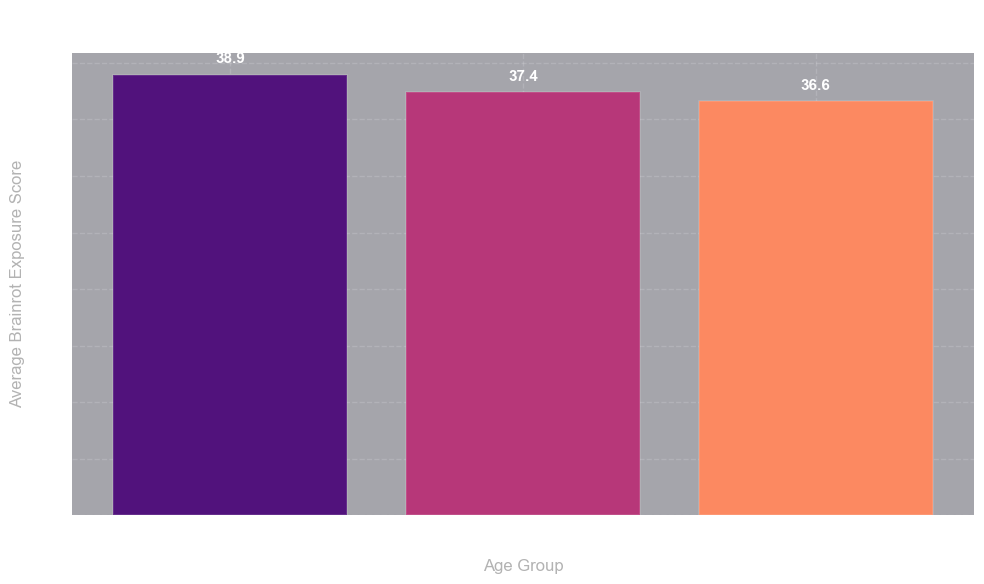

In [ ]:
avg_by_age = final_df.groupby('Age_Group')['Brainrot_Exposure_Score'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 6), facecolor='none')
colors = sns.color_palette("magma", n_colors=len(avg_by_age))
bars = ax.bar(avg_by_age.index, avg_by_age.values, color=colors, edgecolor=(1, 1, 1, 0.15), linewidth=1.2)
apply_premium_theme(ax, title='Average Brainrot Exposure Score by Age Group', xlabel='Age Group', ylabel='Average Brainrot Exposure Score')

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width() / 2, height),xytext=(0, 6), textcoords="offset points", ha='center', va='bottom', color='white', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{charts_dir}/brainrot_score_by_age_group.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor(), transparent=True)
plt.show()

## 4. Wellbeing Score by Region

**Chart type: Horizontal Bar Chart**

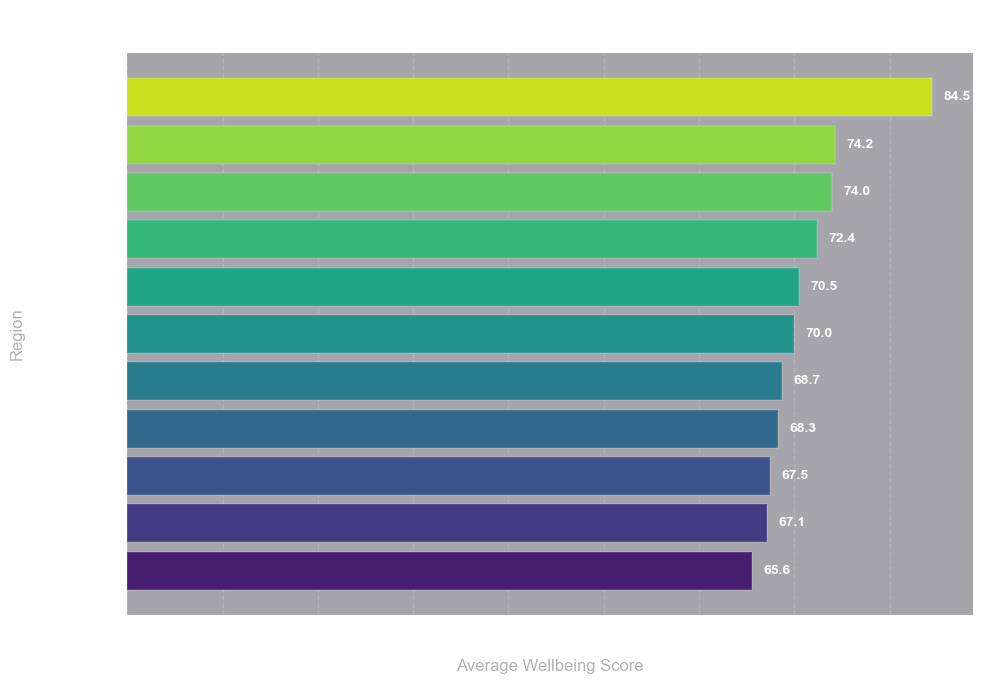

In [ ]:
avg_wellbeing_region = final_df.groupby('Region')['Wellbeing_Score'].mean().sort_values()
fig, ax = plt.subplots(figsize=(10, 7), facecolor='none')
colors = sns.color_palette("viridis", n_colors=len(avg_wellbeing_region))
bars = ax.barh(avg_wellbeing_region.index, avg_wellbeing_region.values, color=colors, edgecolor=(1, 1, 1, 0.15), linewidth=1.2)
apply_premium_theme(ax, title='Average Wellbeing Score by Region', xlabel='Average Wellbeing Score', ylabel='Region',show_x_grid=True)
ax.grid(axis='y', visible=False) 

for bar in bars:
    width = bar.get_width()
    ax.annotate(f'{width:.1f}',xy=(width, bar.get_y() + bar.get_height() / 2),xytext=(8, 0),textcoords="offset points",ha='left', va='center', color='white', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{charts_dir}/wellbeing_by_region.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor(), transparent=True)
plt.show()

## 5. Distribution of Brainrot Exposure Score

**Chart type: Histogram**

C:\Users\mahmo\AppData\Local\Temp\ipykernel_13088\3631812484.py:8: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(axis='x', visible=show_x_grid, linestyle='--', alpha=0.15, color='white')


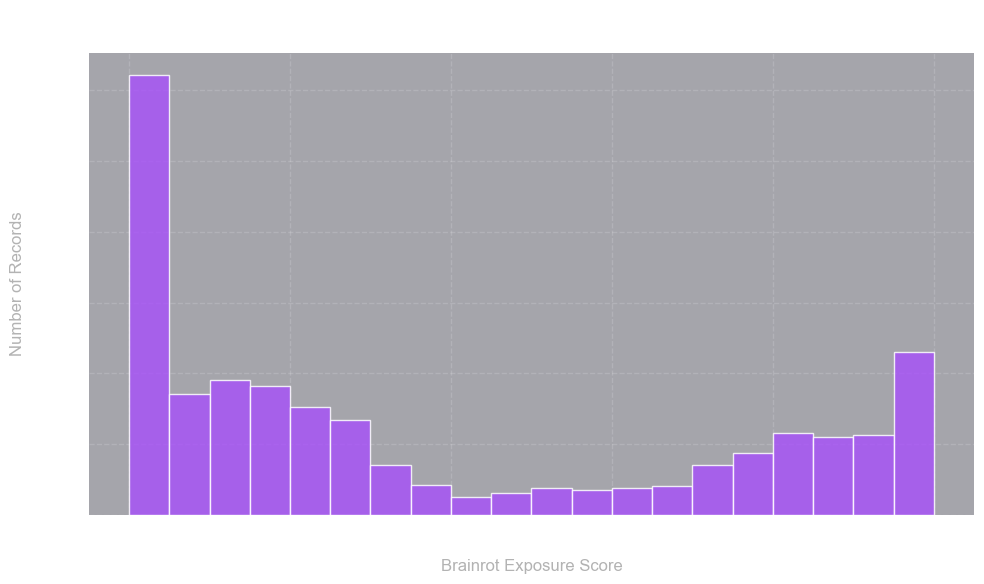

In [39]:
fig, ax = plt.subplots(figsize=(10, 6), facecolor='none')
n, bins, patches = ax.hist(final_df['Brainrot_Exposure_Score'], bins=20, color='#a855f7',edgecolor=(1, 1, 1, 0.2),alpha=0.85)
apply_premium_theme(ax, title='Distribution of Brainrot Exposure Score', xlabel='Brainrot Exposure Score', ylabel='Number of Records',show_x_grid=False )
plt.tight_layout()
plt.savefig(f"{charts_dir}/brainrot_score_histogram.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor(), transparent=True)
plt.show()

## 6. Device Type Share

**Chart type: Pie Chart**

C:\Users\mahmo\AppData\Local\Temp\ipykernel_13088\3631812484.py:8: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(axis='x', visible=show_x_grid, linestyle='--', alpha=0.15, color='white')


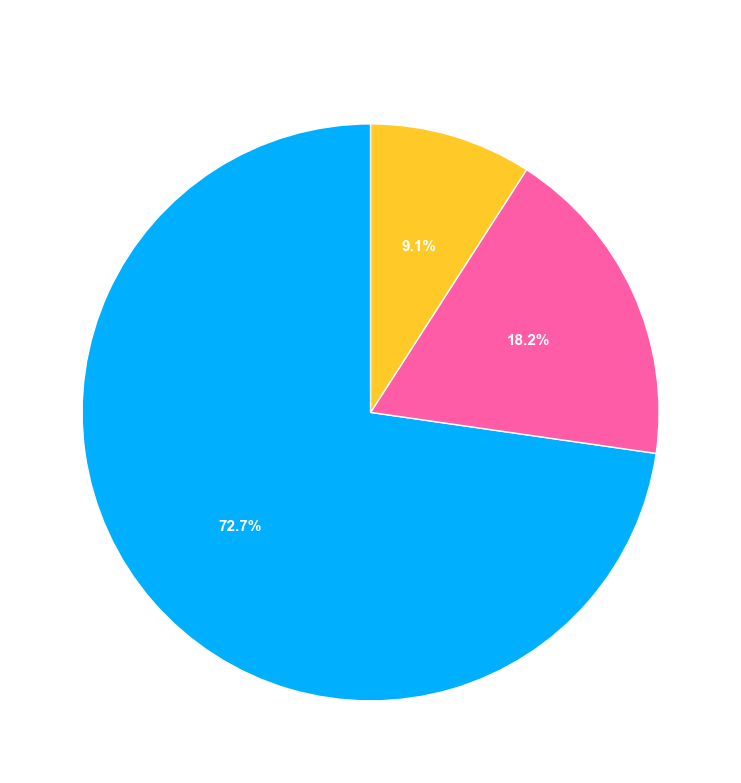

In [ ]:
device_counts = users['Device_Type'].value_counts()
fig, ax = plt.subplots(figsize=(8, 8), facecolor='none')
modern_colors = ['#00b0ff', '#ff5ca8', '#ffca28']
wedges, texts, autotexts = ax.pie(device_counts.values,labels=device_counts.index,autopct='%1.1f%%',startangle=90,colors=modern_colors,textprops=dict(color="white", fontsize=12) )

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_weight('bold')

apply_premium_theme(ax, title='Device Type Share Among Users', xlabel='', ylabel='',show_x_grid=False)
ax.grid(False)
plt.tight_layout()
plt.savefig(f"{charts_dir}/device_type_pie.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor(), transparent=True)
plt.show()

## 7. Reels Watched Over the Year

**Chart type: Line Chart**

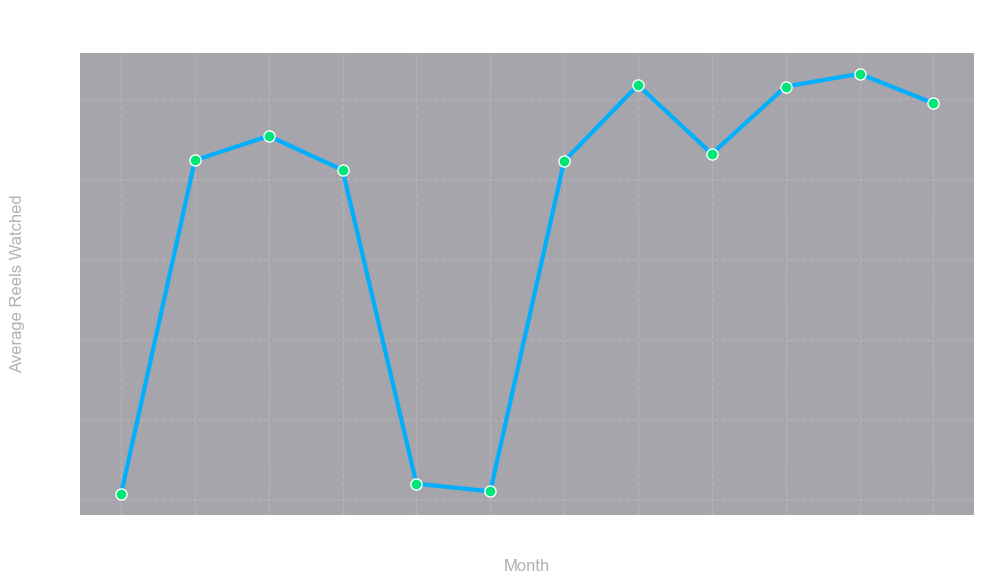

In [41]:
reels_by_month = final_df.groupby('Month')['Total_Reels_Watched'].mean()
fig, ax = plt.subplots(figsize=(10, 6), facecolor='none')
ax.plot(reels_by_month.index, reels_by_month.values, marker='o', markersize=8,markerfacecolor='#00e676',      markeredgecolor='white',color='#00b0ff',               linewidth=3)
apply_premium_theme(ax, title='Average Reels Watched per Month', xlabel='Month', ylabel='Average Reels Watched',show_x_grid=True)
ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.savefig(f"{charts_dir}/reels_over_time.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor(), transparent=True)
plt.show()

## 8. Study Hours vs Brainrot Exposure Score

**Chart type: Scatter Plot**

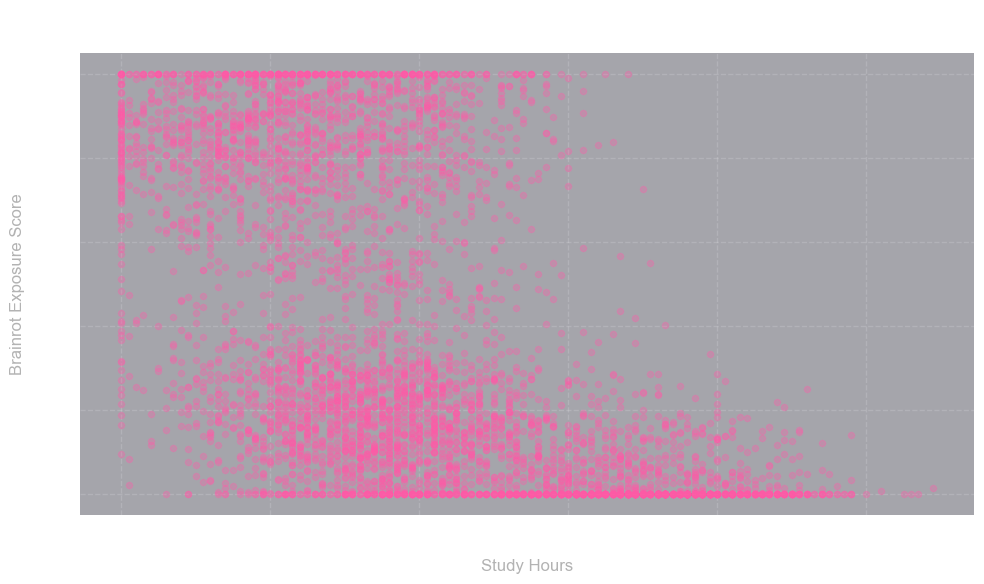

In [42]:
fig, ax = plt.subplots(figsize=(10, 6), facecolor='none')
ax.scatter(final_df['Study_Hours'], final_df['Brainrot_Exposure_Score'], alpha=0.3, color='#ff5ca8',         s=20                   )
apply_premium_theme(ax, title='Study Hours vs Brainrot Exposure Score', xlabel='Study Hours', ylabel='Brainrot Exposure Score',show_x_grid=True         )
plt.tight_layout()
plt.savefig(f"{charts_dir}/study_hours_vs_brainrot.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor(), transparent=True)
plt.show()

## 9. Study Hours by Age Group

**Chart type: Box Plot**

C:\Users\mahmo\AppData\Local\Temp\ipykernel_13088\3631812484.py:8: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(axis='x', visible=show_x_grid, linestyle='--', alpha=0.15, color='white')


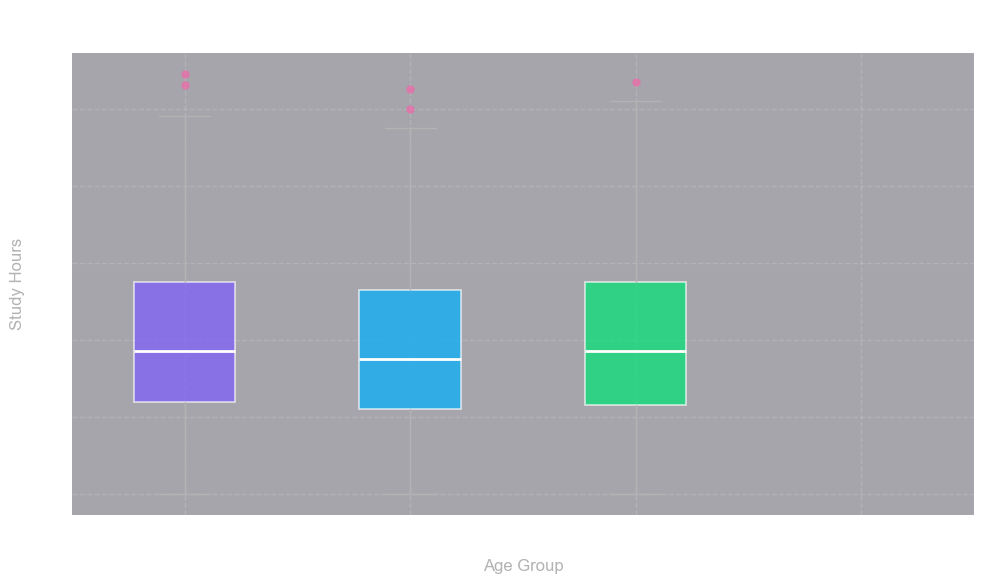

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6), facecolor='none')
age_groups = final_df['Age_Group'].unique().tolist()
data_for_box = [final_df[final_df['Age_Group'] == group]['Study_Hours'].values for group in age_groups]
box = ax.boxplot(data_for_box, tick_labels=age_groups,patch_artist=True,flierprops=dict(marker='o', markerfacecolor='#ff5ca8', markersize=6, markeredgecolor='none', alpha=0.6))
box_colors = ['#7c5cff', '#00b0ff', '#00e676', '#ffca28', '#ff5ca8'][:len(age_groups)]

for patch, color in zip(box['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7) 
    patch.set_edgecolor((1, 1, 1, 0.3))  
    patch.set_linewidth(1.2)

for median in box['medians']:
    median.set_color('white')
    median.set_linewidth(2)

for whisker in box['whiskers']:
    whisker.set_color('#b3b3b3')
    whisker.set_linewidth(1)

for cap in box['caps']:
    cap.set_color('#b3b3b3')

apply_premium_theme(ax, title='Study Hours Distribution by Age Group', xlabel='Age Group', ylabel='Study Hours',show_x_grid=False)
plt.tight_layout()
plt.savefig(f"{charts_dir}/study_hours_boxplot.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor(), transparent=True)
plt.show()

## 10. Device Type Usage by Age Group

**Chart type: Stacked Bar Chart**

C:\Users\mahmo\AppData\Local\Temp\ipykernel_13088\3631812484.py:8: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(axis='x', visible=show_x_grid, linestyle='--', alpha=0.15, color='white')


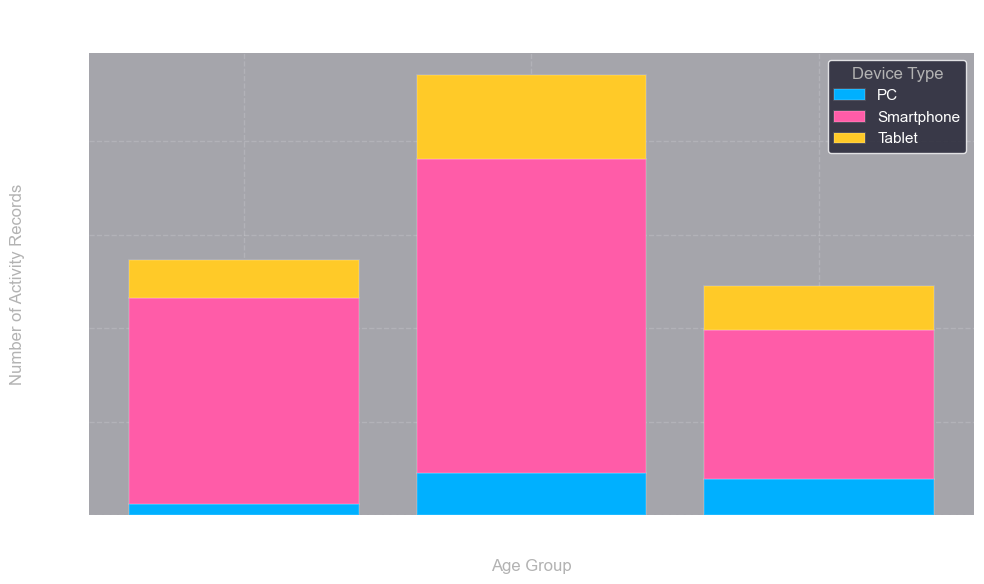

In [ ]:
device_table = pd.crosstab(final_df['Age_Group'], final_df['Device_Type'])
bottom_values = np.zeros(len(device_table))
fig, ax = plt.subplots(figsize=(10, 6), facecolor='none')
modern_colors = ['#00b0ff', '#ff5ca8', '#ffca28']

for i, device in enumerate(device_table.columns):
    ax.bar(device_table.index, device_table[device].values, bottom=bottom_values, label=device, color=modern_colors[i],edgecolor=(1, 1, 1, 0.15), linewidth=1.2)
    bottom_values = bottom_values + device_table[device].values

apply_premium_theme(ax, title='Device Type Usage by Age Group (Stacked)', xlabel='Age Group', ylabel='Number of Activity Records',show_x_grid=False)
legend = ax.legend(title='Device Type', facecolor=(30/255, 30/255, 47/255, 0.6), edgecolor=(1, 1, 1, 0.15), loc='upper right')
plt.setp(legend.get_texts(), color='white')
plt.setp(legend.get_title(), color='#b3b3b3')
plt.tight_layout()
plt.savefig(f"{charts_dir}/stacked_bar_device_by_age.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor(), transparent=True)
plt.show()

## 11. Brainrot Exposure vs Wellbeing Over the Year

**Chart type: Multiple Line Chart**

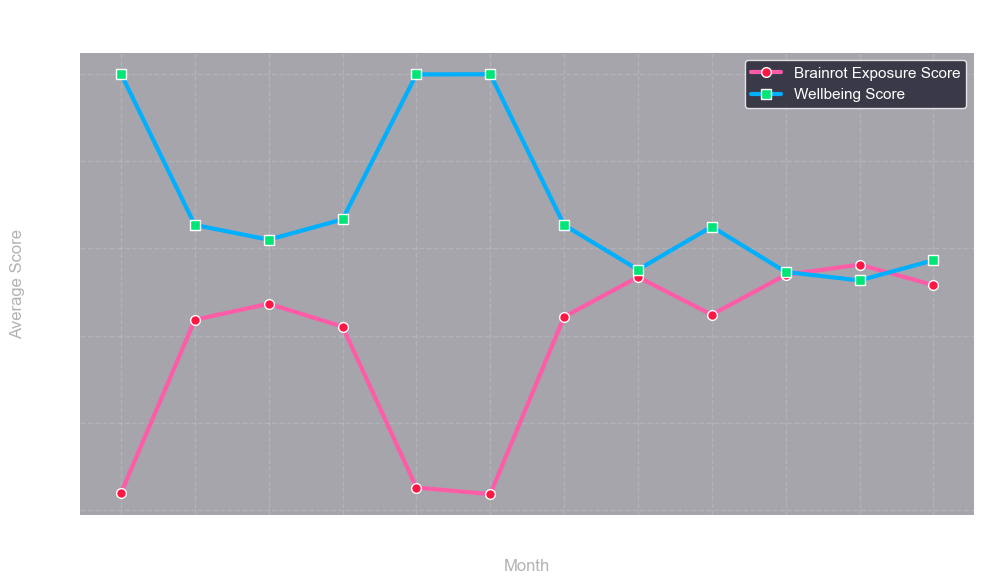

In [ ]:
brainrot_by_month = final_df.groupby('Month')['Brainrot_Exposure_Score'].mean()
wellbeing_by_month = final_df.groupby('Month')['Wellbeing_Score'].mean()
fig, ax = plt.subplots(figsize=(10, 6), facecolor='none')
ax.plot(brainrot_by_month.index, brainrot_by_month.values, marker='o', markersize=7,markerfacecolor='#ff1744', markeredgecolor='white',label='Brainrot Exposure Score', color='#ff5ca8', linewidth=3)
ax.plot(wellbeing_by_month.index, wellbeing_by_month.values, marker='s', markersize=7,markerfacecolor='#00e676', markeredgecolor='white',label='Wellbeing Score', color='#00b0ff', linewidth=3)
apply_premium_theme(ax, title='Brainrot Exposure vs Wellbeing Score Over the Year', xlabel='Month', ylabel='Average Score',show_x_grid=True )
ax.set_xticks(range(1, 13))
legend = ax.legend(facecolor=(30/255, 30/255, 47/255, 0.6), edgecolor=(1, 1, 1, 0.15), loc='upper right')
plt.setp(legend.get_texts(), color='white')
plt.tight_layout()
plt.savefig(f"{charts_dir}/multiple_line_brainrot_wellbeing.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor(), transparent=True)
plt.show()

## 12. Cumulative Reels Watched Over the Year

**Chart type: Area Chart**

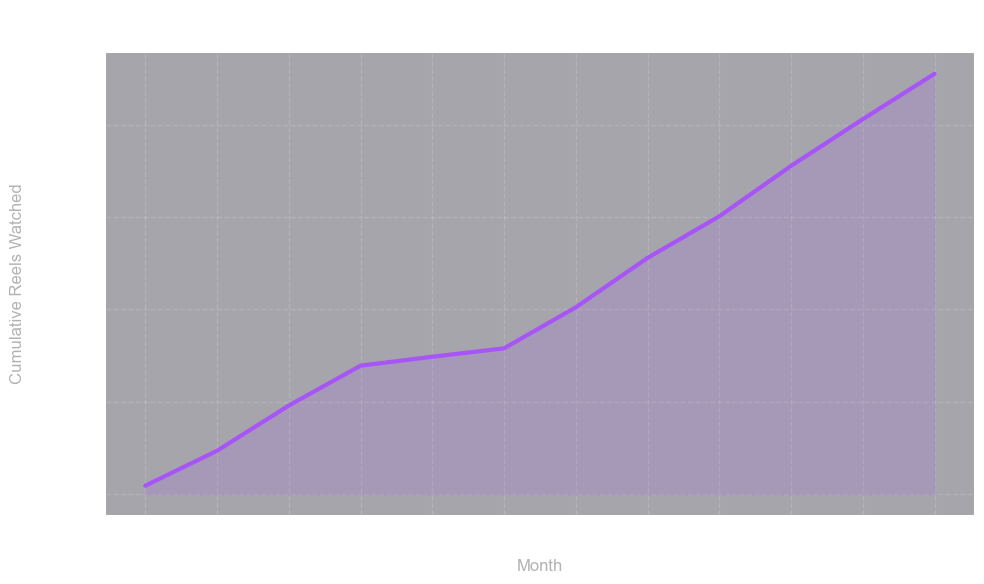

In [ ]:
reels_by_month_sum = final_df.groupby('Month')['Total_Reels_Watched'].sum()
cumulative_reels = reels_by_month_sum.cumsum()
fig, ax = plt.subplots(figsize=(10, 6), facecolor='none')
ax.fill_between(cumulative_reels.index, cumulative_reels.values, color='#a855f7', alpha=0.15 )
ax.plot(cumulative_reels.index, cumulative_reels.values, color='#a855f7', linewidth=3)
apply_premium_theme(ax, title='Cumulative Reels Watched Over the Year', xlabel='Month', ylabel='Cumulative Reels Watched',show_x_grid=True )
ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.savefig(f"{charts_dir}/area_chart_cumulative_reels.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor(),  transparent=True)
plt.show()

## 13. Average Wellbeing Score by Age Group (with Variation)

**Chart type: Error Bar Chart**

C:\Users\mahmo\AppData\Local\Temp\ipykernel_13088\3631812484.py:8: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(axis='x', visible=show_x_grid, linestyle='--', alpha=0.15, color='white')


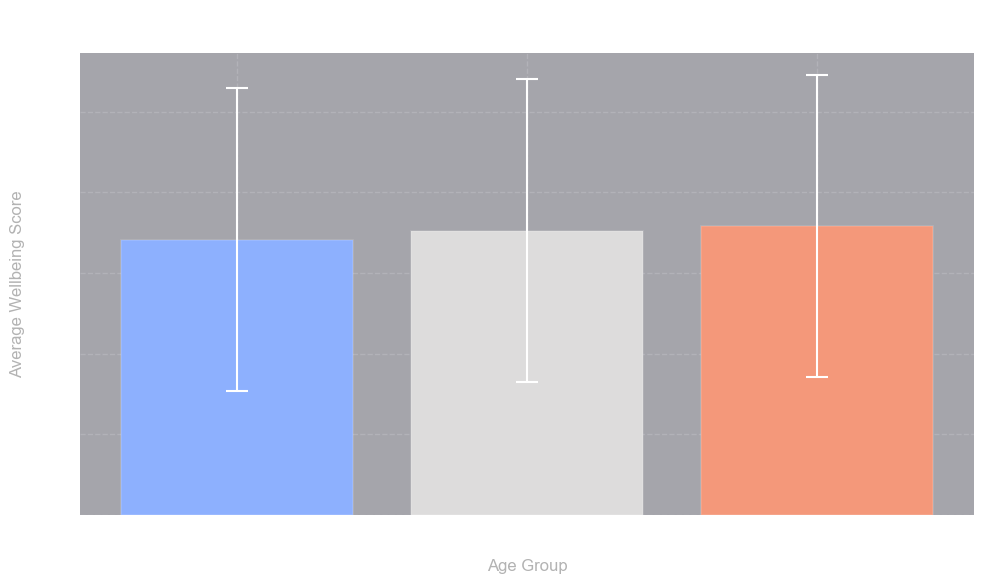

In [ ]:
mean_wellbeing = final_df.groupby('Age_Group')['Wellbeing_Score'].mean()
std_wellbeing = final_df.groupby('Age_Group')['Wellbeing_Score'].std()
fig, ax = plt.subplots(figsize=(10, 6), facecolor='none')
colors = sns.color_palette("coolwarm", n_colors=len(mean_wellbeing))
bars = ax.bar(mean_wellbeing.index, mean_wellbeing.values, yerr=std_wellbeing.values, capsize=8, color=colors, edgecolor=(1, 1, 1, 0.15), linewidth=1.2,error_kw=dict(ecolor='white', elinewidth=1.5, capthick=1.5) )
apply_premium_theme(ax, title='Average Wellbeing Score by Age Group (with Standard Deviation)', xlabel='Age Group', ylabel='Average Wellbeing Score',show_x_grid=False)
plt.tight_layout()
plt.savefig(f"{charts_dir}/error_bar_wellbeing_age.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor(), transparent=True)
plt.show()

## 14. Weekday vs Weekend Brainrot Exposure by Region

**Chart type: Grouped Bar Chart**

C:\Users\mahmo\AppData\Local\Temp\ipykernel_13088\3631812484.py:8: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(axis='x', visible=show_x_grid, linestyle='--', alpha=0.15, color='white')


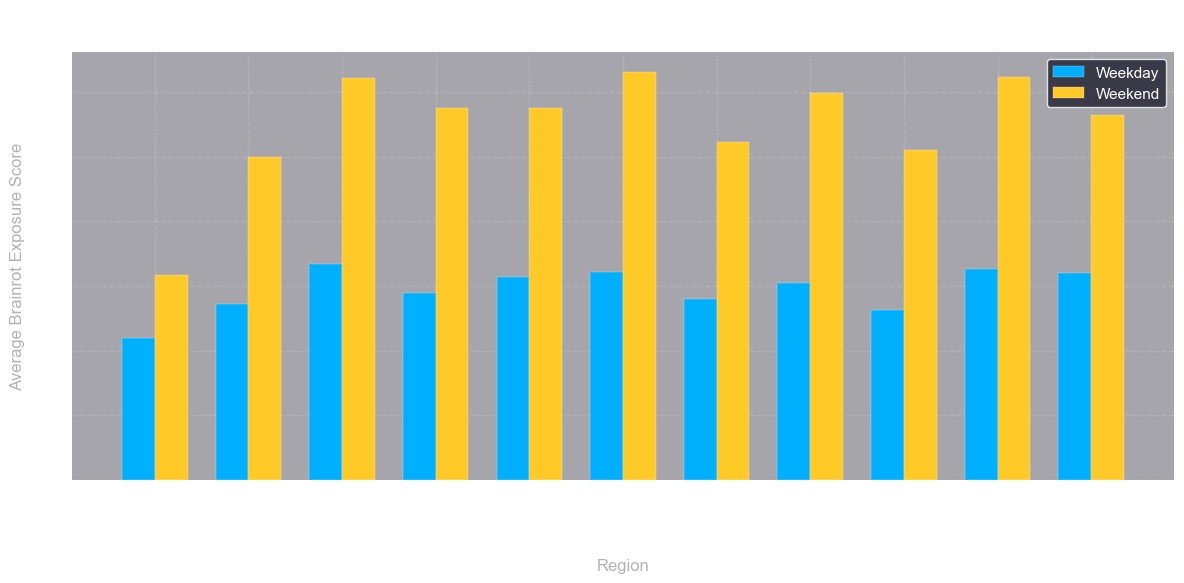

In [ ]:
grouped = final_df.groupby(['Region', 'Is_Weekend'])['Brainrot_Exposure_Score'].mean().unstack()
regions = grouped.index.tolist()
x_positions = np.arange(len(regions))
bar_width = 0.35
fig, ax = plt.subplots(figsize=(12, 6), facecolor='none')
bars_weekday = ax.bar(x_positions - bar_width/2, grouped[0].values, bar_width, label='Weekday', color='#00b0ff', edgecolor=(1, 1, 1, 0.15), linewidth=1.2)
bars_weekend = ax.bar(x_positions + bar_width/2, grouped[1].values, bar_width, label='Weekend', color='#ffca28',edgecolor=(1, 1, 1, 0.15), linewidth=1.2)
apply_premium_theme(ax, title='Average Brainrot Exposure Score: Weekday vs Weekend by Region', xlabel='Region', ylabel='Average Brainrot Exposure Score',show_x_grid=False)
ax.set_xticks(x_positions)
ax.set_xticklabels(regions, rotation=30, ha='right', color='white')
legend = ax.legend(facecolor=(30/255, 30/255, 47/255, 0.6), edgecolor=(1, 1, 1, 0.15), loc='upper right')
plt.setp(legend.get_texts(), color='white')
plt.tight_layout()
plt.savefig(f"{charts_dir}/grouped_bar_region_weekend.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor(), transparent=True)
plt.show()

## 15. Correlation Heatmap

**Chart type: Correlation Heatmap (matplotlib only)**

C:\Users\mahmo\AppData\Local\Temp\ipykernel_13088\3631812484.py:8: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(axis='x', visible=show_x_grid, linestyle='--', alpha=0.15, color='white')


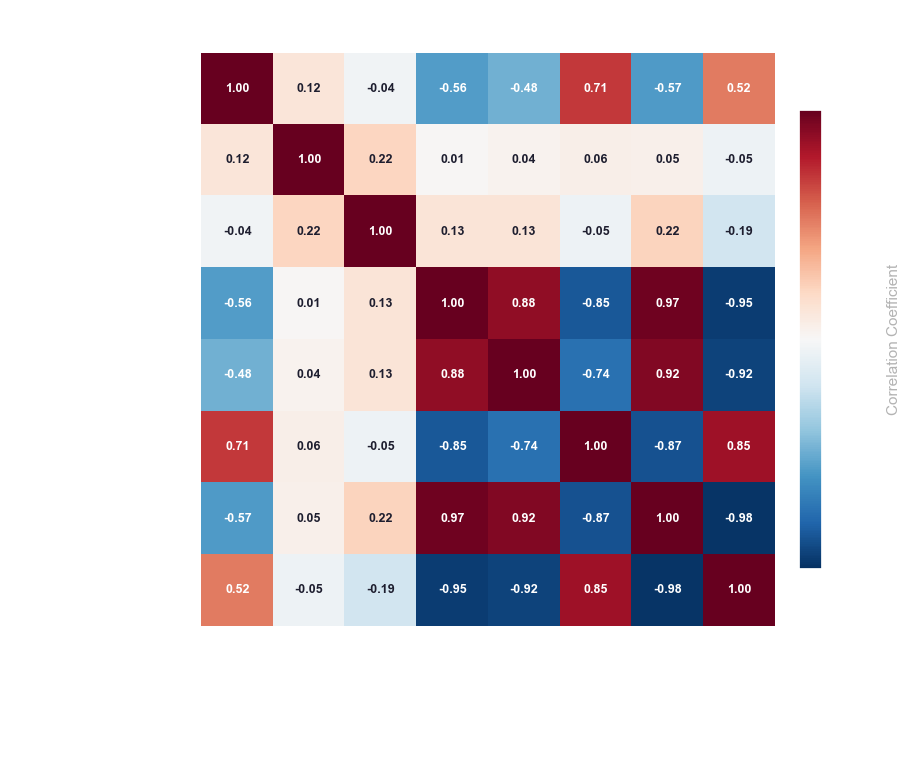

In [ ]:
numeric_cols = [
    'Study_Hours', 'Coffee_Consumed_Per_Day', 'Smoking_Breaks_Count', 'Total_Reels_Watched',
    'Short_Content_Percentage', 'Focus_Sessions_Count', 'Brainrot_Exposure_Score', 'Wellbeing_Score'
]
corr_matrix = final_df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8), facecolor='none')
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
cbar = fig.colorbar(im, ax=ax, pad=0.03, shrink=0.8)
cbar.set_label('Correlation Coefficient', color='#b3b3b3', fontsize=11, labelpad=10)
cbar.ax.yaxis.set_tick_params(color='white', labelcolor='white')

for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.4 else '#1e1e2f'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9, fontweight='bold',color=color)

apply_premium_theme(ax, title='Correlation Heatmap of Numeric Columns', xlabel='', ylabel='',show_x_grid=False)
ax.grid(False)
ax.set_xticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right', color='white', fontsize=10)
ax.set_yticks(range(len(numeric_cols)))
ax.set_yticklabels(numeric_cols, color='white', fontsize=10)
plt.tight_layout()
plt.savefig(f"{charts_dir}/correlation_heatmap.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor(), transparent=True)
plt.show()

## 16. Brainrot Stage Distribution

**Chart type: Pie Chart**

C:\Users\mahmo\AppData\Local\Temp\ipykernel_13088\3631812484.py:8: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(axis='x', visible=show_x_grid, linestyle='--', alpha=0.15, color='white')


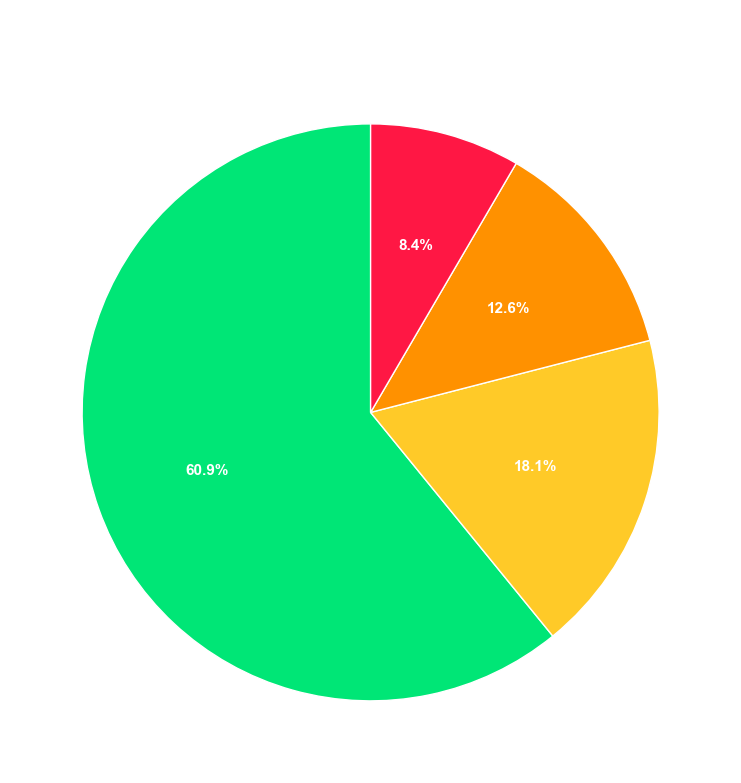

In [ ]:
stage_counts = final_df['Brainrot_Stage'].value_counts()
fig, ax = plt.subplots(figsize=(8, 8), facecolor='none')
modern_stage_colors = ['#00e676', '#ffca28', '#ff9100', '#ff1744']
wedges, texts, autotexts = ax.pie(stage_counts.values,labels=stage_counts.index,autopct='%1.1f%%',startangle=90,colors=modern_stage_colors,textprops=dict(color="white", fontsize=12) )

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_weight('bold')

apply_premium_theme(ax, title='Brainrot Stage Distribution', xlabel='', ylabel='',show_x_grid=False)
ax.grid(False)
plt.tight_layout()
plt.savefig(f"{charts_dir}/brainrot_stage_distribution.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor(), transparent=True)
plt.show()